# Mestrado em Inteligência Artificial 25/26


# Practical 2 — Markov Decision Processes (MDPs) with Gridworld


In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "agents").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".mplconfig"))

from envs.gridworld import ACTIONS, Gridworld
from experiments.gridworld_dp import (
    bellman_expectation_update,
    greedy_policy_from_V,
    policy_evaluation,
    policy_evaluation_Q,
    value_iteration,
    zeros_Q,
    zeros_V,
)
from plots.gridworld import plot_grid_values_and_policy
from policies.gridworld import uniform_random_policy

np.set_printoptions(precision=3, suppress=True)


## 1) Gridworld MDP


In [2]:
env = Gridworld()
ACTIONS, env.states()[:5], env.terminal_states


(('U', 'D', 'L', 'R'),
 [(0, 0), (0, 1), (0, 2), (0, 3), (1, 0)],
 ((0, 0), (3, 3)))

### Quick sanity checks


In [3]:
print("From (0,1) with U:", env.transition((0, 1), "U"))
print("From (0,1) with L:", env.transition((0, 1), "L"))
print("From (0,0) with R:", env.transition((0, 0), "R"))


From (0,1) with U: ((0, 1), -1.0, False)
From (0,1) with L: ((0, 0), -1.0, True)
From (0,0) with R: ((0, 0), 0.0, True)


## 2) Utilities: indexing states and initializing V


In [4]:
V0 = zeros_V(env)
Q0 = zeros_Q(env)
V0, Q0.shape


(array([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]]),
 (4, 4, 4))

## 3) Policy definition


In [5]:
policy = uniform_random_policy(env)
policy[(1, 1)]


{'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25}

In [6]:
policy


{(0, 0): {'U': 0.0, 'D': 0.0, 'L': 0.0, 'R': 0.0},
 (0, 1): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (0, 2): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (0, 3): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (1, 0): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (1, 1): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (1, 2): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (1, 3): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (2, 0): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (2, 1): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (2, 2): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (2, 3): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (3, 0): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (3, 1): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (3, 2): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (3, 3): {'U': 0.0, 'D': 0.0, 'L': 0.0, 'R': 0.0}}

## 4) Policy Evaluation (compute $V_{\pi}$)


In [7]:
gamma = 0.9
sample_update = bellman_expectation_update(env, V0, policy, (1, 1), gamma)
V_pi, iters = policy_evaluation(env, policy, gamma=gamma, theta=1e-8)
print("Sample Bellman expectation update at (1,1):", sample_update)
print("Converged in iterations:", iters)
V_pi


Sample Bellman expectation update at (1,1): -1.0
Converged in iterations: 77


array([[ 0.   , -5.278, -7.128, -7.651],
       [-5.278, -6.606, -7.181, -7.128],
       [-7.128, -7.181, -6.606, -5.278],
       [-7.651, -7.128, -5.278,  0.   ]])

## 5) Value Iteration (approximate $V^{*}$)


In [8]:
V_star, iters_vi = value_iteration(env, gamma=gamma, theta=1e-8)
print("Converged in iterations:", iters_vi)
V_star


Converged in iterations: 4


array([[ 0.  , -1.  , -1.9 , -2.71],
       [-1.  , -1.9 , -2.71, -1.9 ],
       [-1.9 , -2.71, -1.9 , -1.  ],
       [-2.71, -1.9 , -1.  ,  0.  ]])

In [9]:
pi_star = greedy_policy_from_V(env, V_star, gamma=gamma)
pi_star[(2, 2)], pi_star[(0, 1)], pi_star[(1, 0)]


('D', 'L', 'U')

## 5.5) Compute the action-value function $Q^{\pi}$


In [10]:
Q_pi, itq = policy_evaluation_Q(env, policy, gamma=gamma, theta=1e-8)
print("Q^pi converged in iterations:", itq)
Q_pi[1, 1]


Q^pi converged in iterations: 118


array([-5.75 , -7.463, -5.75 , -7.463])

## 6) Visualization


In [11]:
from plots.gridworld import ARROW
ARROW


{'U': '↑', 'D': '↓', 'L': '←', 'R': '→', '.': '.'}

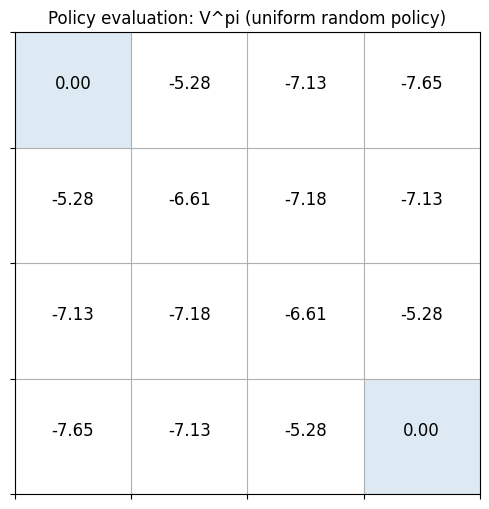

In [12]:
fig, ax = plot_grid_values_and_policy(
    env,
    V_pi,
    None,
    title="Policy evaluation: V^pi (uniform random policy)",
)
plt.show()


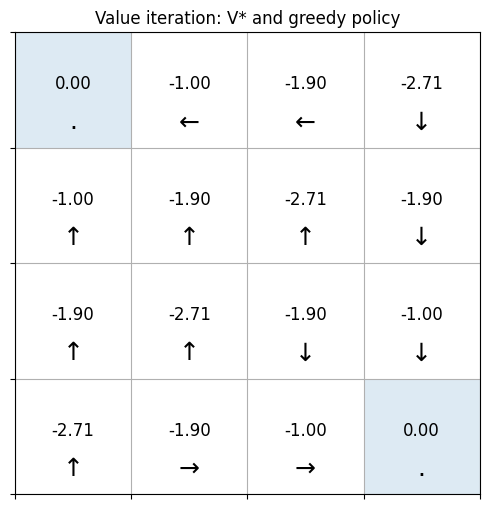

In [13]:
fig, ax = plot_grid_values_and_policy(
    env,
    V_star,
    pi_star,
    title="Value iteration: V* and greedy policy",
)
plt.show()


## 7) Exercises

The main notebook content ends above. The items below are optional extensions and are intentionally left without implementation here.


This section is left as an extension space for extra variants of the base GridWorld.
The core notebook ends above with policy evaluation, value iteration, and visualization.


### Exercise B — Add a "trap" cell

Optional extension: modify the environment dynamics or rewards to include a penalizing trap state.


### Exercise C — Make the environment stochastic

Optional extension: replace deterministic transitions with action slippage or transition probabilities.
